
# 📊 EDA de un portafolio de activos con Python
### Matplotlib · Seaborn · Pandas · yfinance

**Curso:** Lenguajes de programación  
**Tema:** Visualización y Análisis Exploratorio de Datos (EDA)  
**Caso:** análisis exploratorio de un portafolio de activos financieros

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook podrás:

- reconocer qué es una librería y para qué sirve;
- diferenciar **dato, variable, gráfico e interpretación**;
- crear gráficos básicos con **Matplotlib**;
- utilizar **Seaborn** para explorar distribuciones y relaciones;
- interpretar correctamente los gráficos;
- descargar datos históricos con **yfinance**;
- calcular rendimientos;
- explorar volatilidad, distribución y correlación;
- construir una primera lectura exploratoria de un portafolio.

> **Idea central:** un gráfico no es el resultado del análisis.  
> El gráfico es una herramienta que nos ayuda a **formular preguntas, encontrar patrones y comunicar hallazgos**.



## 🧭 Ruta de la clase

Trabajaremos de manera incremental:

**1. Datos → 2. Variables → 3. Gráfico → 4. Interpretación → 5. EDA → 6. Datos financieros reales**

| Etapa | Pregunta |
|---|---|
| Conceptos | ¿Qué estamos visualizando? |
| Matplotlib | ¿Cómo se construye un gráfico? |
| Seaborn | ¿Cómo exploramos una variable o relación? |
| EDA | ¿Qué patrones encontramos? |
| yfinance | ¿Cómo trabajamos con datos reales? |
| Portafolio | ¿Cómo se comportan conjuntamente los activos? |



# 1. Antes de graficar: pensemos como analistas

Supongamos que tenemos:

| Día | Precio |
|---:|---:|
| 1 | 100 |
| 2 | 103 |
| 3 | 101 |
| 4 | 108 |
| 5 | 112 |

Tenemos dos conceptos diferentes:

### Variable
Una característica que podemos observar o medir.  
Ejemplo: `Precio`.

### Observación
Un valor concreto de una variable.  
Ejemplo: el precio del día 4 es `108`.

### ¿Por qué graficar?

La tabla nos da los valores. El gráfico nos permite **ver la estructura de los datos**.

Por ejemplo:

- ¿el precio está aumentando?
- ¿hay caídas?
- ¿hay cambios bruscos?
- ¿existe una tendencia?

Ese proceso de preguntar, observar y encontrar patrones forma parte del **Análisis Exploratorio de Datos (EDA)**.



# 2. Las librerías que vamos a utilizar

Una **librería** es un conjunto de código reutilizable que otras personas han desarrollado para resolver problemas.

Hoy utilizaremos:

### 🐼 Pandas
Para trabajar con datos tabulares.

### 📈 Matplotlib
Para construir y personalizar visualizaciones.

### 🎨 Seaborn
Para crear visualizaciones estadísticas de forma sencilla y trabajar cómodamente con DataFrames.

### 💰 yfinance
Para obtener datos históricos de activos financieros desde Yahoo Finance.

La relación será:

```text
yfinance
   ↓
datos financieros
   ↓
Pandas
   ↓
transformaciones
   ↓
Matplotlib / Seaborn
   ↓
visualización
   ↓
interpretación
```


In [ ]:
# Importamos las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline



## ¿Qué significa `import`?

Cuando escribimos:

```python
import matplotlib.pyplot as plt
```

estamos diciendo:

> "Quiero utilizar el módulo `pyplot` de la librería `matplotlib` y voy a llamarlo `plt`."

Por eso posteriormente podemos escribir:

```python
plt.plot(...)
```

El nombre `plt` es un **alias**. No es obligatorio llamarlo así, pero es una convención muy utilizada.

Lo mismo ocurre con:

```python
import seaborn as sns
import pandas as pd
import numpy as np
```



# 3. Nuestro primer gráfico: de una tabla a una visualización

Comencemos con datos muy pequeños para entender **qué hace cada instrucción**.

Tenemos el precio de un activo durante cinco días.


In [ ]:
dias = [1, 2, 3, 4, 5]
precios = [100, 103, 101, 108, 112]

datos_ejemplo = pd.DataFrame({
    "Día": dias,
    "Precio": precios
})

datos_ejemplo



### Primer intento

Queremos representar:

- eje X → día
- eje Y → precio

La función `plot()` recibe normalmente una serie de valores para X y otra para Y.


In [ ]:
plt.plot(dias, precios)
plt.show()



## 🔎 ¿Qué acaba de ocurrir?

`plt.plot(x, y)`:

- toma los valores de `x`;
- toma los valores de `y`;
- coloca cada par `(x, y)` en el plano;
- conecta los puntos.

En nuestro ejemplo:

```text
(1,100)
(2,103)
(3,101)
(4,108)
(5,112)
```

### ¿Cómo lo interpretamos?

No debemos decir simplemente "el gráfico sube".

Podemos decir:

> **El precio presenta una tendencia general creciente durante el período observado, aunque existe una disminución entre los días 2 y 3.**

Esa segunda frase ya es una **interpretación**.



# 4. Hacer que el gráfico comunique mejor

Un gráfico debe permitir que otra persona entienda rápidamente:

1. **qué está viendo**;
2. **qué representan los ejes**;
3. **qué unidad se está utilizando**;
4. **qué período se está observando**.

Para eso agregamos título y etiquetas.


In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(dias, precios)

plt.title("Evolución del precio")
plt.xlabel("Día")
plt.ylabel("Precio")

plt.show()



## 🧩 Anatomía de un gráfico

```text
                 TÍTULO
        Evolución del precio

  Y
  ↑
  │             ●
  │          ●
  │     ●
  │        ●
  │  ●
  └──────────────────────→ X
       Día
```

### Elementos principales

- **Título:** comunica qué estamos observando.
- **Eje X:** normalmente representa tiempo o una variable explicativa.
- **Eje Y:** representa la variable que queremos analizar.
- **Línea/puntos:** representan los datos.
- **Leyenda:** identifica las series cuando tenemos varias.



# 5. La interfaz orientada a objetos de Matplotlib

Hasta ahora utilizamos `plt` directamente.

Existe otra forma muy importante:

```python
fig, ax = plt.subplots()
```

Aquí aparecen dos objetos:

### `fig`
Es la **figura completa**, el espacio donde estará nuestro gráfico.

### `ax`
Es el **área de ejes** donde realmente dibujamos.

Una forma sencilla de imaginarlo:

```text
Figure
┌─────────────────────────────┐
│                             │
│       Axes                  │
│     ┌───────────────┐       │
│     │   gráfico     │       │
│     │               │       │
│     └───────────────┘       │
│                             │
└─────────────────────────────┘
```


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dias, precios)

ax.set_title("Evolución del precio")
ax.set_xlabel("Día")
ax.set_ylabel("Precio")

plt.show()



### ¿Por qué aprender esta forma?

Cuando los gráficos se vuelven más complejos, trabajar con `fig` y `ax` nos da mayor control.

Por ejemplo, podemos tener varios gráficos dentro de una misma figura y controlar cada eje por separado.

**Regla práctica para la clase:**

- `plt.plot()` → muy útil para comenzar.
- `fig, ax = plt.subplots()` → recomendable cuando queremos construir gráficos de forma más estructurada.



# 6. Gráficos de varias series

Ahora supongamos que tenemos tres activos.


In [ ]:
precios_portafolio = pd.DataFrame({
    "AAPL": [100, 103, 101, 108, 112],
    "MSFT": [100, 102, 104, 106, 109],
    "NVDA": [100, 98, 105, 110, 120]
}, index=[1, 2, 3, 4, 5])

precios_portafolio



Si graficamos los precios directamente, podemos comparar las series.

Pero aparece un problema importante:

> ¿Cómo comparamos activos que originalmente tienen precios diferentes?

Por ahora nuestros datos comienzan todos en 100. Esto es intencional: queremos concentrarnos en la **forma de la serie** antes de introducir los rendimientos.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(precios_portafolio.index, precios_portafolio["AAPL"], label="AAPL")
ax.plot(precios_portafolio.index, precios_portafolio["MSFT"], label="MSFT")
ax.plot(precios_portafolio.index, precios_portafolio["NVDA"], label="NVDA")

ax.set_title("Evolución de tres activos")
ax.set_xlabel("Día")
ax.set_ylabel("Precio normalizado")
ax.legend()

plt.show()



## 🧠 Interpretación

Observe primero, **después interprete**.

Preguntas:

1. ¿Cuál serie termina más arriba?
2. ¿Cuál presenta más cambios?
3. ¿Hay momentos en los que dos activos se mueven en direcciones diferentes?
4. ¿Podemos concluir cuál es "mejor" solamente con este gráfico?

La última pregunta es importante:

> **No.** Un gráfico puede mostrar comportamiento histórico, pero no convierte automáticamente ese comportamiento en una recomendación de inversión.



# 7. Seaborn: visualización orientada al análisis estadístico

Seaborn está construido sobre Matplotlib y facilita muchos gráficos estadísticos.

Una ventaja importante es que puede trabajar directamente con estructuras de Pandas.

Vamos a utilizar primero un **histograma**.


In [ ]:
# Generamos una muestra sencilla de rendimientos

np.random.seed(42)

rendimientos_ejemplo = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=500
)

rendimientos_ejemplo[:10]



## ¿Qué pregunta responde un histograma?

Un histograma permite observar cómo se distribuyen los valores.

Por ejemplo:

> ¿En qué rango se concentran los rendimientos?


In [ ]:
sns.histplot(
    rendimientos_ejemplo,
    bins=30,
    kde=True
)

plt.title("Distribución de rendimientos")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.show()



## 🔎 ¿Cómo interpretar un histograma?

Observemos:

### Centro
¿Dónde se concentran la mayoría de los valores?

### Dispersión
¿Qué tan extendidos están los datos?

### Colas
¿Hay valores alejados del centro?

### Forma
¿La distribución parece simétrica o presenta algún sesgo?

**Importante:** la forma del histograma depende de decisiones como el número de `bins`. No debemos interpretar cada detalle visual como una propiedad exacta de los datos.



# 8. Boxplot: detectar dispersión y valores extremos

Un boxplot resume visualmente una distribución.

Conceptualmente muestra:

- mediana;
- cuartiles;
- rango intercuartílico;
- posibles valores extremos.



In [ ]:
sns.boxplot(y=rendimientos_ejemplo)

plt.title("Distribución de rendimientos")
plt.ylabel("Rendimiento")

plt.show()



### Preguntas para interpretar

- ¿Dónde está la mediana?
- ¿Qué tan grande es la caja?
- ¿Qué tan largos son los bigotes?
- ¿Aparecen observaciones alejadas?

El objetivo no es memorizar la forma del dibujo.

El objetivo es poder decir:

> "La distribución presenta mayor/menor dispersión..."

y justificarlo a partir del gráfico.



# 9. Scatter plot: estudiar relaciones

Ahora queremos estudiar dos variables.

Por ejemplo:

> ¿Los cambios diarios de AAPL y MSFT tienden a ocurrir en la misma dirección?

Para eso usamos un **scatter plot**.

Cada punto representa una observación.


In [ ]:
np.random.seed(10)

aapl = np.random.normal(0.001, 0.02, 100)
msft = aapl * 0.6 + np.random.normal(0, 0.015, 100)

sns.scatterplot(x=aapl, y=msft)

plt.title("Relación entre rendimientos")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



## Interpretación

Buscamos patrones:

- nube ascendente → posible relación positiva;
- nube descendente → posible relación negativa;
- nube sin orientación clara → relación lineal débil o inexistente.

Pero recuerda:

> **Correlación no significa causalidad.**

Dos variables pueden moverse juntas sin que una sea la causa de la otra.



# 10. Correlación y mapa de calor

La correlación permite cuantificar la relación lineal entre dos variables.

En Python:

```python
df.corr()
```

produce una matriz de correlaciones.

Valores cercanos a:

- `1` → relación lineal positiva fuerte;
- `0` → relación lineal débil;
- `-1` → relación lineal negativa fuerte.

Veámoslo visualmente.


In [ ]:
datos_rendimientos = pd.DataFrame({
    "AAPL": aapl,
    "MSFT": msft,
    "NVDA": aapl * 0.3 + np.random.normal(0, 0.025, 100)
})

correlacion = datos_rendimientos.corr()

correlacion


In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()



## 🧠 Interpretar el heatmap

La matriz permite responder rápidamente:

> ¿Qué activos tienen comportamientos más similares?

Pero debemos tener cuidado:

- la correlación mide principalmente **relación lineal**;
- una correlación histórica no garantiza que se mantenga igual;
- correlación no significa causalidad;
- el período elegido afecta el resultado.

Para un análisis financiero serio también debemos considerar el período, frecuencia, calidad de datos y contexto del mercado.



# 11. Ahora sí: datos reales con yfinance 💰

Hasta este momento utilizamos datos pequeños o simulados para entender la visualización.

Ahora vamos a trabajar con datos reales.

Instalación, si el entorno todavía no tiene la librería:

```bash
pip install yfinance
```

Importamos:


In [ ]:
import yfinance as yf



## ¿Qué activos vamos a estudiar?

Usaremos como ejemplo:

- `AAPL` — Apple
- `MSFT` — Microsoft
- `GOOGL` — Alphabet
- `AMZN` — Amazon
- `NVDA` — NVIDIA

Los símbolos son **tickers**, identificadores utilizados para localizar activos en los mercados.

> Los datos obtenidos mediante servicios externos pueden cambiar con el tiempo. Para una clase de EDA esto es útil: cada estudiante puede obtener una fotografía diferente del período consultado.


In [ ]:
activos = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()



# 12. Antes de graficar: conozcamos nuestros datos

Una regla fundamental de EDA:

> **No empieces a graficar sin conocer primero el DataFrame.**

Preguntas básicas:

- ¿cuántas filas tenemos?
- ¿cuántas columnas?
- ¿qué tipo de datos?
- ¿hay valores faltantes?
- ¿qué período cubren?


In [ ]:
print("Dimensiones:", precios.shape)

precios.info()


In [ ]:
precios.describe()


In [ ]:
precios.isna().sum()



### 🧪 Mini-reto

Antes de continuar, responde:

1. ¿Cuántas observaciones tenemos?
2. ¿Cuál es la primera fecha?
3. ¿Cuál es la última fecha?
4. ¿Existen valores faltantes?
5. ¿Qué representa cada nivel de columnas?

**No continúes hasta intentar responderlas.**



# 13. Seleccionar el precio de cierre

`yfinance` devuelve varias variables para cada activo, entre ellas:

- Open
- High
- Low
- Close
- Volume

Para nuestro primer análisis utilizaremos **Close**, el precio de cierre ajustado según la configuración utilizada.



In [ ]:
cierre = precios["Close"]

cierre.head()



## Visualicemos los precios

Primera pregunta del EDA:

> **¿Cómo evolucionaron los precios de los activos durante el período?**


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()



## ⚠️ Una dificultad de comparar precios

AAPL puede tener un precio nominal diferente de NVDA, MSFT, etc.

Eso hace que comparar las alturas directamente pueda ser engañoso.

Una solución sencilla para estudiar **crecimiento relativo** es normalizar las series.

Por ejemplo:

```python
precio_normalizado = precio / precio_inicial * 100
```

Así todos comienzan en 100.


In [ ]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()



### ¿Qué pregunta responde este gráfico?

No responde:

> "¿Cuál tiene el precio más alto?"

Responde mejor:

> **"¿Cómo cambió cada activo respecto a su propio punto inicial?"**

Esta distinción es fundamental en análisis de datos financieros.



# 14. Rendimientos: transformar los precios

En análisis financiero suele ser útil estudiar **rendimientos** en lugar de precios.

Un rendimiento porcentual simple entre dos períodos puede calcularse como:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

En Pandas podemos obtenerlo con:

```python
pct_change()
```


In [ ]:
rendimientos = cierre.pct_change()

rendimientos.head()



El primer registro normalmente será `NaN` porque no tenemos un precio anterior con el cual compararlo.

Eliminemos esos valores para las visualizaciones que lo necesiten.


In [ ]:
rendimientos = rendimientos.dropna()

rendimientos.head()



# 15. EDA de los rendimientos

### Pregunta 1
**¿Cómo se comportan los rendimientos a través del tiempo?**


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()



### Interpretación

La línea horizontal en cero nos ayuda a distinguir:

- valores positivos → rendimiento positivo;
- valores negativos → rendimiento negativo.

Busca:

- períodos de mayor variabilidad;
- movimientos extremos;
- momentos donde varios activos caen simultáneamente;
- diferencias entre activos.

**No confundas variabilidad con rendimiento.**

Un activo puede tener grandes movimientos hacia arriba y hacia abajo y terminar cerca del punto inicial.



# 16. Distribución de rendimientos

Ahora usamos Seaborn para estudiar una variable desde otro ángulo.

Pregunta:

> **¿Cómo se distribuyen los rendimientos diarios de cada activo?**


In [ ]:
sns.histplot(
    data=rendimientos,
    x="AAPL",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - AAPL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()



## 🧪 Cambia el activo

Modifica `"AAPL"` por:

```python
"MSFT"
"GOOGL"
"AMZN"
"NVDA"
```

### Pregunta

¿Qué diferencias observas entre las distribuciones?

No busques solamente cuál "se ve mejor".

Describe:

- centro;
- dispersión;
- valores extremos;
- forma de la distribución.



# 17. Comparar la dispersión con un boxplot

Ahora podemos comparar todos los activos simultáneamente.


In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()



### Preguntas de análisis

1. ¿Qué activos muestran mayor dispersión?
2. ¿Qué activos presentan más observaciones alejadas?
3. ¿Las medianas están cerca de cero?
4. ¿Qué información perderíamos si solo observáramos el precio?

Aquí aparece una idea importante:

> **Una buena visualización permite comparar una propiedad concreta de los datos.**



# 18. Matriz de correlación del portafolio

Ahora llegamos a una de las visualizaciones más importantes para nuestro caso.

Pregunta:

> **¿Cómo se relacionan los rendimientos de los activos entre sí?**


In [ ]:
correlacion = rendimientos.corr()

correlacion


In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()



## 🧠 ¿Cómo leer la matriz?

Supongamos que encontramos:

```text
             AAPL    MSFT
AAPL          1.00   0.70
MSFT          0.70   1.00
```

La diagonal es 1 porque cada activo está perfectamente correlacionado consigo mismo.

Un valor de `0.70` indica una relación lineal positiva relativamente alta en el período analizado.

### Pregunta de portafolio

Si dos activos presentan una correlación elevada:

> ¿Qué implica esto para la diversificación?

Una posible interpretación es que **pueden proporcionar menos diversificación entre sí que dos activos con una correlación menor**, aunque la diversificación real depende de muchos otros factores.

No debemos convertir la correlación, por sí sola, en una recomendación de inversión.



# 19. Scatter plot: profundicemos en una pareja

Seleccionemos dos activos:

```python
AAPL
MSFT
```

Cada punto representa un día.

- X → rendimiento de AAPL
- Y → rendimiento de MSFT



In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="AAPL",
    y="MSFT",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: AAPL vs MSFT")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



### Preguntas para interpretar

Observa la nube de puntos:

1. ¿Existe una orientación ascendente?
2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
3. ¿MSFT suele tener el mismo signo?
4. ¿Hay valores extremos?
5. ¿La relación parece perfectamente lineal?

El scatter plot y la matriz de correlación están contando historias relacionadas, pero desde perspectivas diferentes:

**Scatter → vemos las observaciones individuales.**  
**Correlación → resumimos numéricamente la relación lineal.**



# 20. Estadísticas descriptivas del portafolio

La visualización debe complementarse con medidas numéricas.



In [ ]:
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen



## ¿Qué estamos viendo?

### Media
Promedio de los rendimientos.

### Mediana
Valor central de la distribución.

### Desviación estándar
Medida de dispersión utilizada frecuentemente como una aproximación de la volatilidad histórica.

### Mínimo / máximo
Permiten observar los extremos registrados en el período.

**Importante:** estas estadísticas describen el período analizado. No garantizan que el futuro se comporte igual.



# 21. Mini-proyecto: EDA completo

Ahora debes construir tu propio análisis.

## Objetivo

Selecciona entre **3 y 5 activos** y realiza un EDA.

### Paso 1 — Datos

Descarga los datos históricos.

### Paso 2 — Calidad

Revisa:

- dimensiones;
- tipos;
- valores faltantes;
- período.

### Paso 3 — Precios

Construye un gráfico de evolución de precios.

### Paso 4 — Normalización

Construye un gráfico con todas las series comenzando en 100.

### Paso 5 — Rendimientos

Calcula los rendimientos diarios.

### Paso 6 — Distribución

Construye un histograma para uno de los activos.

### Paso 7 — Comparación

Construye un boxplot de los rendimientos.

### Paso 8 — Relación

Construye una matriz de correlación.

### Paso 9 — Relación entre dos activos

Construye un scatter plot.

### Paso 10 — Conclusiones

Escribe **3 hallazgos**.

Cada hallazgo debe tener esta estructura:

> **Gráfico:** ¿qué gráfico utilizaste?  
> **Observación:** ¿qué ves?  
> **Interpretación:** ¿qué significa esa observación para el análisis?


## Solución del Mini-proyecto

A continuación, resolvemos los pasos propuestos analizando un nuevo portafolio.

In [1]:
# Paso 1: Datos
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos 4 activos diferentes
mis_activos = ["TSLA", "META", "NFLX", "DIS"]
# Descargamos los datos de 2023 completo
mis_precios = yf.download(mis_activos, start="2023-01-01", end="2024-01-01")["Close"]

# Paso 2: Calidad
print("Dimensiones:", mis_precios.shape)
print("\nValores nulos por columna:\n", mis_precios.isna().sum())
display(mis_precios.head())

/tmp/ipykernel_471/2824055827.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mis_precios = yf.download(mis_activos, start="2023-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  4 of 4 completed

Dimensiones: (250, 4)

Valores nulos por columna:
 Ticker
DIS     0
META    0
NFLX    0
TSLA    0
dtype: int64


Ticker,DIS,META,NFLX,TSLA
Date,,,,
2023-01-03,86.262039,123.556625,29.495001,108.099998
2023-01-04,89.180420,126.161667,30.941000,113.639999
2023-01-05,89.122246,125.735748,30.969999,110.339996
2023-01-06,91.061371,128.786530,31.555000,113.059998
2023-01-09,91.885506,128.241745,31.517000,119.769997


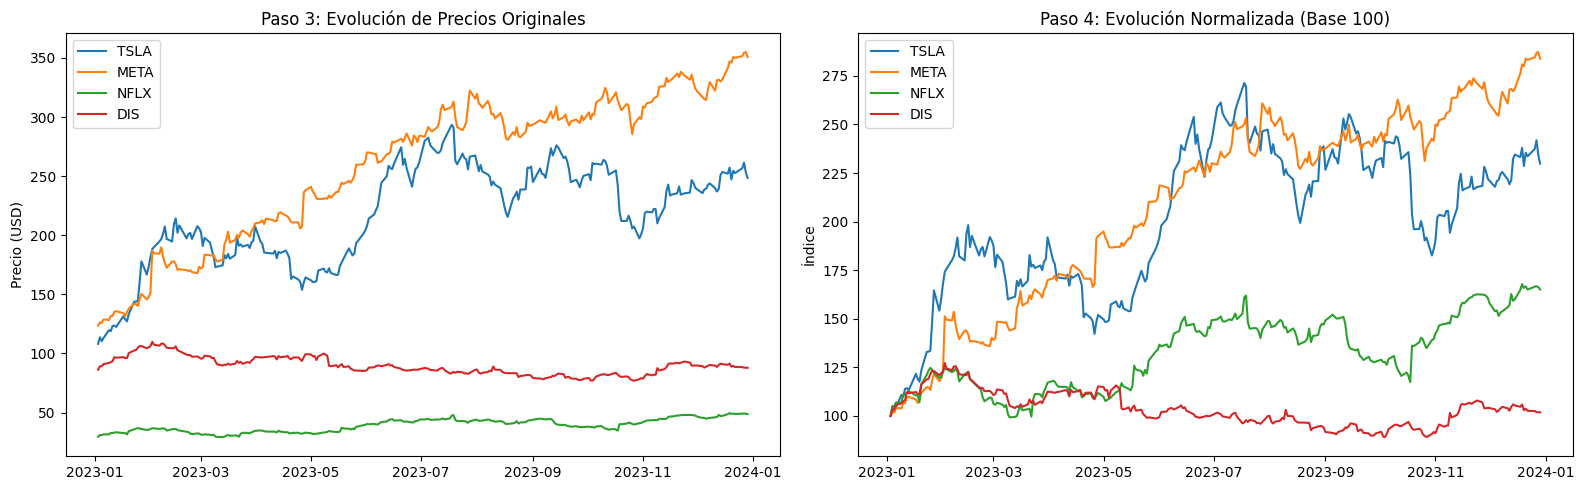

In [2]:
# Paso 3 y 4: Precios y Normalización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Paso 3: Precios originales
for activo in mis_activos:
    axes[0].plot(mis_precios.index, mis_precios[activo], label=activo)
axes[0].set_title("Paso 3: Evolución de Precios Originales")
axes[0].set_ylabel("Precio (USD)")
axes[0].legend()

# Paso 4: Precios normalizados (Base 100)
precios_norm = mis_precios / mis_precios.iloc[0] * 100
for activo in mis_activos:
    axes[1].plot(precios_norm.index, precios_norm[activo], label=activo)
axes[1].set_title("Paso 4: Evolución Normalizada (Base 100)")
axes[1].set_ylabel("Índice")
axes[1].legend()

plt.tight_layout()
plt.show()

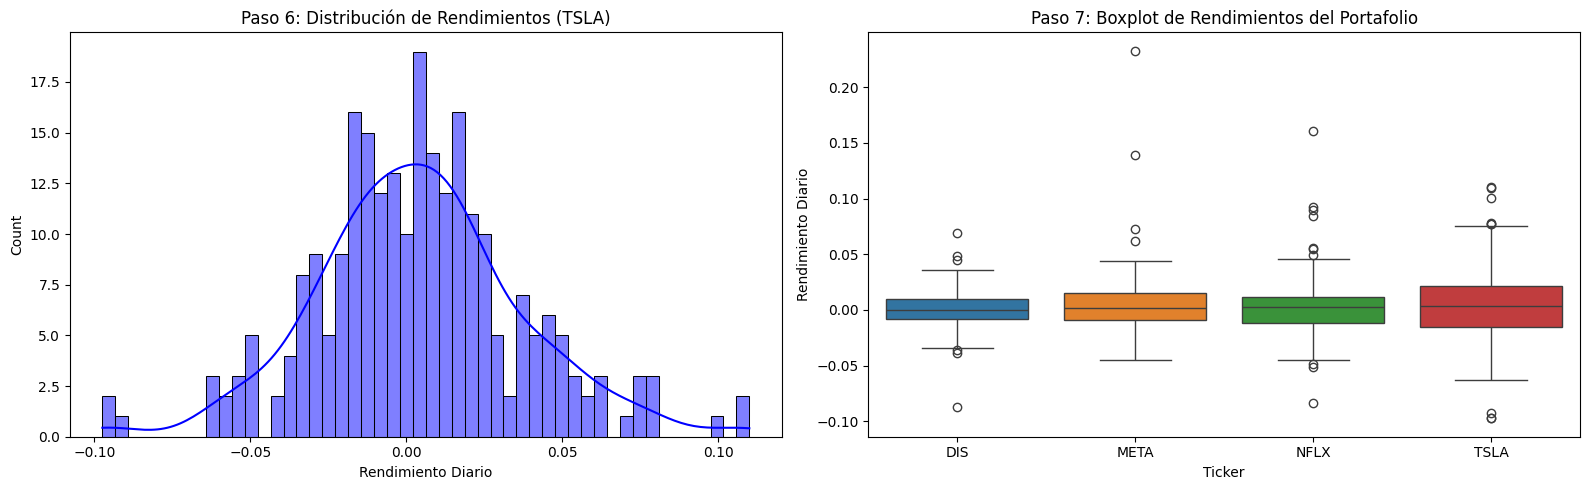

In [3]:
# Paso 5: Rendimientos
mis_rendimientos = mis_precios.pct_change().dropna()

# Paso 6 y 7: Distribución (Histograma y Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Paso 6: Histograma de un activo (ej. TSLA)
sns.histplot(data=mis_rendimientos, x="TSLA", bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title("Paso 6: Distribución de Rendimientos (TSLA)")
axes[0].set_xlabel("Rendimiento Diario")

# Paso 7: Boxplot de todo el portafolio
sns.boxplot(data=mis_rendimientos, ax=axes[1])
axes[1].set_title("Paso 7: Boxplot de Rendimientos del Portafolio")
axes[1].set_ylabel("Rendimiento Diario")

plt.tight_layout()
plt.show()

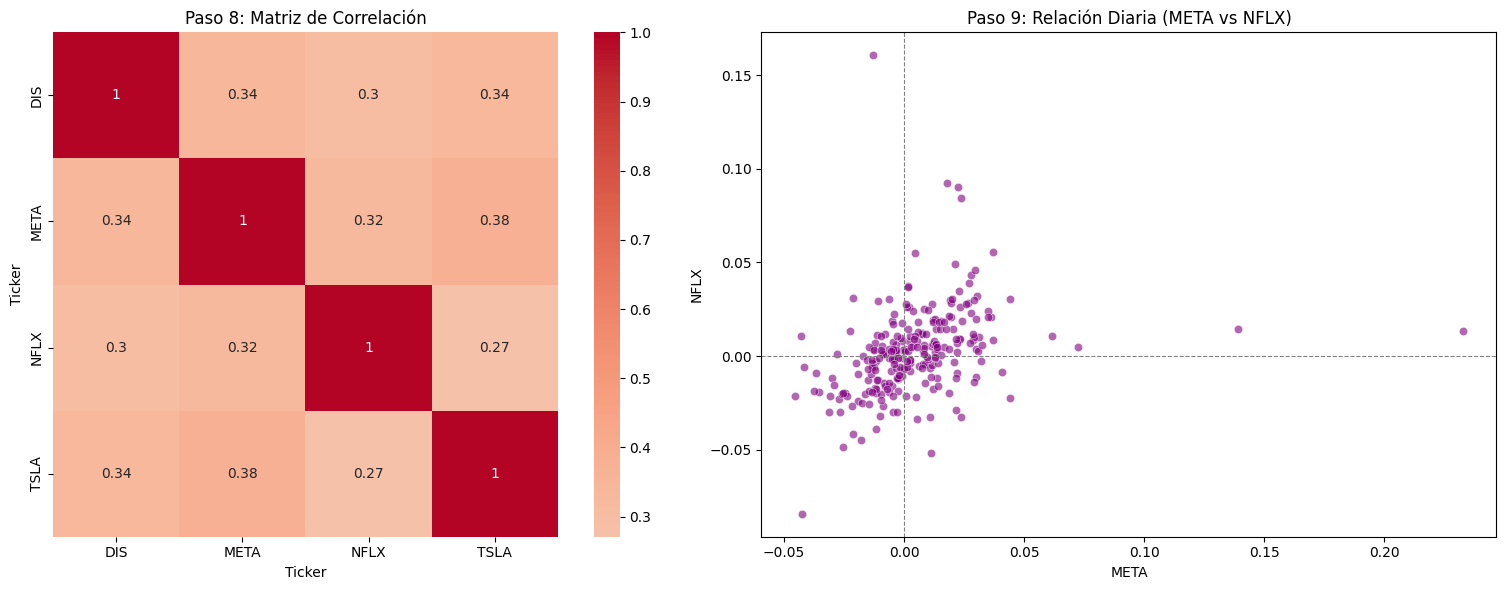

In [4]:
# Paso 8 y 9: Correlación y Relación (Scatter)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paso 8: Matriz de correlación
corr_matrix = mis_rendimientos.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Paso 8: Matriz de Correlación")

# Paso 9: Scatter plot (META vs NFLX)
sns.scatterplot(data=mis_rendimientos, x="META", y="NFLX", alpha=0.6, ax=axes[1], color='purple')
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].axvline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_title("Paso 9: Relación Diaria (META vs NFLX)")

plt.tight_layout()
plt.show()

### Paso 10: Conclusiones

1. **Gráfico:** Evolución Normalizada (Paso 4)
   - **Observación:** Las líneas de META se separan considerablemente hacia arriba en comparación con el resto de los activos a partir de la primera mitad del año, mientras que DIS se mantiene plana o a la baja.
   - **Interpretación:** META tuvo un rendimiento acumulado muy superior y constante en 2023 en comparación con el resto del portafolio.

2. **Gráfico:** Boxplot de Rendimientos (Paso 7)
   - **Observación:** La caja y los "bigotes" de TSLA y META son visualmente más amplios que los de DIS y NFLX.
   - **Interpretación:** TSLA y META experimentaron una mayor volatilidad (dispersión de rendimientos diarios), lo que indica un mayor riesgo a corto plazo en este período.

3. **Gráfico:** Matriz de Correlación (Paso 8)
   - **Observación:** Las correlaciones entre los activos fluctúan, pero la mayoría son moderadamente positivas (por ejemplo, META y NFLX). Ninguna correlación está extremadamente cerca de 1.
   - **Interpretación:** Aunque pertenecen parcialmente al mismo sector (tecnología/entretenimiento), los activos no se mueven de forma idéntica, lo cual permite un nivel aceptable de diversificación del riesgo dentro del portafolio.


# 22. Reto final 🎯

Sin modificar el código inicialmente:

### Pregunta 1
¿Cuál activo presenta mayor dispersión de rendimientos?

### Pregunta 2
¿Cuáles dos activos presentan mayor correlación?

### Pregunta 3
¿Cuáles presentan menor correlación?

### Pregunta 4
¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?

### Pregunta 5
¿La evolución normalizada cuenta la misma historia que los precios originales?

### Pregunta 6
¿Qué información aporta el histograma que no aporta el gráfico temporal?

### Pregunta 7
¿Qué información aporta el scatter plot que no aporta el heatmap?

---

## ⭐ Regla de oro del EDA

Antes de hacer un gráfico pregunta:

> **¿Qué quiero saber?**

Después del gráfico pregunta:

> **¿Qué estoy observando?**

Y finalmente:

> **¿Qué puedo concluir razonablemente a partir de lo observado?**



# 📚 Referencias

- [Matplotlib — documentación oficial](https://matplotlib.org/stable/)
- [Matplotlib — galería de ejemplos](https://matplotlib.org/stable/gallery/)
- [Matplotlib — introducción a Figure y Axes](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Seaborn — documentación oficial](https://seaborn.pydata.org/)
- [Pandas — visualización](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [yfinance — documentación](https://ranaroussi.github.io/yfinance/)

### Nota sobre los datos

Los datos obtenidos mediante `yfinance` corresponden a información histórica de mercado y pueden cambiar dependiendo del período consultado, ajustes y disponibilidad. Este notebook tiene finalidad educativa y de análisis de datos; no constituye asesoría financiera.
